In [50]:
import numpy as np

inlet  = np.loadtxt("inlet_p_U.xy")
outlet = np.loadtxt("outlet_p_U.xy")

y_in,  p_in,  Ux_in  = inlet[:,0],  inlet[:,1], inlet[:,2]
y_out, p_out, Ux_out = outlet[:,0], outlet[:,1], outlet[:,2]

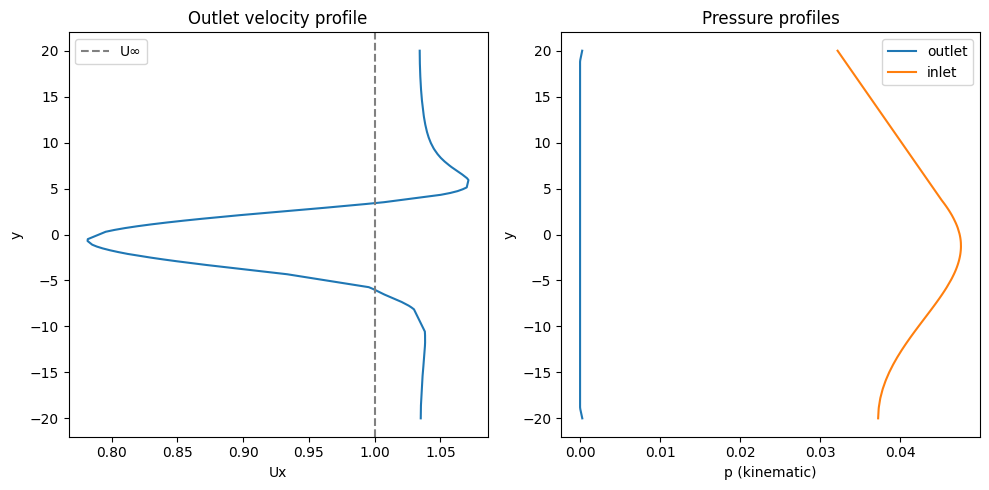

In [51]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(Ux_out, y_out)
ax1.axvline(1.0, color='gray', linestyle='--', label='U∞')
ax1.set_xlabel("Ux")
ax1.set_ylabel("y")
ax1.set_title("Outlet velocity profile")
ax1.legend()

ax2.plot(p_out, y_out, label='outlet')
ax2.plot(p_in,  y_in,  label='inlet')
ax2.set_xlabel("p (kinematic)")
ax2.set_ylabel("y")
ax2.set_title("Pressure profiles")
ax2.legend()

plt.tight_layout()
plt.show()

In [52]:
rho = 1.0   # density
U_inf = 1.0 # velocity at inlet
D = 2.0     # diameter of cylinder
L = 1.0     # span (unit depth for 2D)

# momentum flux: inlet - outlet (trapezoid integration over y)
mom_inlet  = np.trapezoid (rho * Ux_in**2,  y_in)
mom_outlet = np.trapezoid (rho * Ux_out**2, y_out)
momentum_term = mom_inlet - mom_outlet

# pressure force: inlet - outlet (net pressure pushes in x-direction)
p_force_inlet  = np.trapezoid (p_in,  y_in)
p_force_outlet = np.trapezoid (p_out, y_out)
pressure_term = p_force_inlet - p_force_outlet

# total drag force
F_drag = momentum_term + pressure_term

# drag coefficient
Cd_CV = F_drag / (0.5 * rho * U_inf**2 * D * L)

print(f"Momentum term:  {momentum_term:.4f} N")
print(f"Pressure term:  {pressure_term:.4f} N")
print(f"F_drag:         {F_drag:.4f} N")
print(f"Cd (CV):        {Cd_CV:.4f}")

Momentum term:  -0.2082 N
Pressure term:  1.6498 N
F_drag:         1.4416 N
Cd (CV):        1.4416


In [53]:
import pandas as pd

df2 = pd.read_csv("PythonCode/Data/dragCoeff/medium.dat", sep=r"\s+")

time2 = df2["Time"]
Cd2 = df2["Cd"]

df_periodic = df2[df2['Time'] >= 170]

Cd_at_200 = Cd2.iloc[-1]
Cd_mean = df_periodic['Cd'].mean()

print(f"Cd at t=200:   {Cd_at_200}")
print(f"Mean Cd:       {Cd_mean:.4f}")

Cd at t=200:   1.37869
Mean Cd:       1.3850


In [54]:
diff_mean = (Cd_CV / Cd_mean) - 1
diff_last = (Cd_CV / Cd_at_200) - 1

print(f"Difference from mean: {diff_mean:.2%}")
print(f"Difference from last value: {diff_last:.2%}")

Difference from mean: 4.08%
Difference from last value: 4.56%


**Cd from mean values**

In [ ]:
# /sample folder holds all data files for inlet_p_U.xy, outlet_p_U.xy for time = 0 to time = 200

# sorting the data to only get time >= 170 for the mean calculation

import numpy as np
import os

sample_dir = "sample"

# get all timestep folders after shedding stabilises
timesteps = sorted([float(t) for t in os.listdir(sample_dir)])
timesteps_stable = [t for t in timesteps if t >= 170]

outlet_Ux_all = []
outlet_p_all  = []
inlet_Ux_all  = []
inlet_p_all   = []

for t in timesteps_stable:
    folder = f"{sample_dir}/{t:.2f}".rstrip('0').rstrip('.')
    try:
        inn = np.loadtxt(f"{folder}/inlet_p_U.xy")
        out = np.loadtxt(f"{folder}/outlet_p_U.xy")
        inlet_Ux_all.append(inn[:,2])
        inlet_p_all.append(inn[:,1])
        outlet_Ux_all.append(out[:,2])
        outlet_p_all.append(out[:,1])
    except FileNotFoundError:
        pass

# time average
Ux_in_avg  = np.mean(inlet_Ux_all,  axis=0)
p_in_avg   = np.mean(inlet_p_all,   axis=0)
Ux_out_avg = np.mean(outlet_Ux_all, axis=0)
p_out_avg  = np.mean(outlet_p_all,  axis=0)

y_in  = inn[:,0]
y_out = out[:,0]

rho   = 1.0
U_inf = 1.0
D     = 2.0
L     = 1.0

# time average
Ux_in_avg  = np.mean(inlet_Ux_all,  axis=0)
p_in_avg   = np.mean(inlet_p_all,   axis=0)
Ux_out_avg = np.mean(outlet_Ux_all, axis=0)
p_out_avg  = np.mean(outlet_p_all,  axis=0)

# use correct y arrays for each face
mom_in        = np.trapezoid(rho * Ux_in_avg**2,  y_in)
mom_out       = np.trapezoid(rho * Ux_out_avg**2, y_out)
mom_term      = mom_in - mom_out

p_in_int      = np.trapezoid(p_in_avg,  y_in)
p_out_int     = np.trapezoid(p_out_avg, y_out)
pressure_term = p_in_int - p_out_int

F_drag        = mom_term + pressure_term
Cd_CV         = F_drag / (0.5 * rho * U_inf**2 * D * L)

Cd_OF = df2['Cd'][df2['Time'] >= 170].mean()

print(f"Momentum term:  {mom_term:.4f} N")
print(f"Pressure term:  {pressure_term:.4f} N")
print(f"F_drag:         {F_drag:.4f} N")
print(f"Cd (CV):        {Cd_CV:.4f}")
print(f"Cd (OpenFOAM):  {Cd_OF:.4f}")
print(f"Difference:     {abs(Cd_CV - Cd_OF)/Cd_OF*100:.2f}%")

Total timesteps available: 800
Stable timesteps (t>=170): 121
Momentum term:  -0.2011 N
Pressure term:  1.6620 N
F_drag:         1.4610 N
Cd (CV):        1.4610
Cd (OpenFOAM):  1.3850
Difference:     5.48%
